In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [7]:
# 1. Load Dataset
data = pd.read_csv("Datasets/BEED_Data.csv")

X = data.iloc[:, 0:16].values
y = data.iloc[:, 16].values

print("Dataset Shape:", data.shape)
print("Class Distribution:\n", pd.Series(y).value_counts())

Dataset Shape: (8000, 17)
Class Distribution:
 0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [8]:
# 2. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)


Random Forest Accuracy: 0.95625

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       600
           1       0.97      0.95      0.96       600
           2       0.94      0.95      0.94       600
           3       0.92      0.93      0.92       600

    accuracy                           0.96      2400
   macro avg       0.96      0.96      0.96      2400
weighted avg       0.96      0.96      0.96      2400



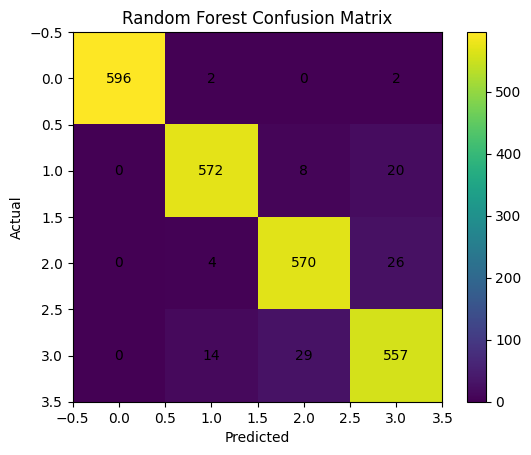

In [10]:
# Part A: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Accuracy:", accuracy_rf)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure()
plt.imshow(cm_rf)
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
# Part B: GRU Model (PyTorch)

# Reshape for GRU: (batch, seq_len, features)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(2)  # (batch, seq_len=16, input_size=1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(2)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Define GRU Model
class GRUClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, num_classes=4):
        super(GRUClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 100)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(100, num_classes)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]  # Take last time step
        out = torch.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

In [12]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gru_model = GRUClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

In [13]:
# Train GRU
num_epochs = 50
train_acc_list = []
test_acc_list = []

for epoch in range(num_epochs):
    gru_model.train()
    correct = 0
    total = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = gru_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    train_acc = correct / total
    train_acc_list.append(train_acc)
    
    # Evaluate on test set
    gru_model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = gru_model(batch_X)
            _, predicted = torch.max(outputs.data, 1)
            total_test += batch_y.size(0)
            correct_test += (predicted == batch_y).sum().item()
    test_acc = correct_test / total_test
    test_acc_list.append(test_acc)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}")

Epoch 10/50, Train Acc: 0.742, Test Acc: 0.740
Epoch 20/50, Train Acc: 0.897, Test Acc: 0.887
Epoch 30/50, Train Acc: 0.939, Test Acc: 0.924
Epoch 40/50, Train Acc: 0.963, Test Acc: 0.925
Epoch 50/50, Train Acc: 0.977, Test Acc: 0.951


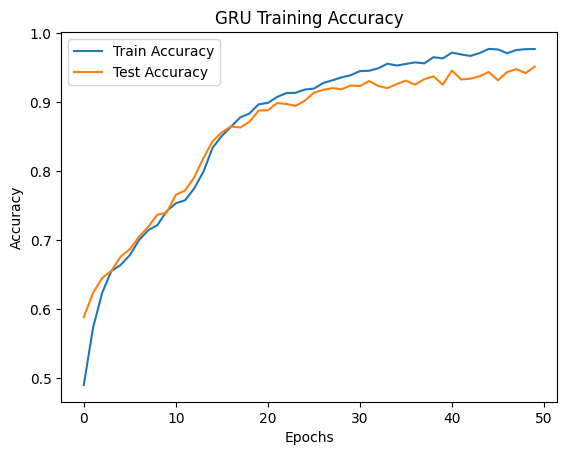

In [14]:
# Plot training & test accuracy
plt.figure()
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.title('GRU Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
# Evaluate GRU
gru_model.eval()
all_preds = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        outputs = gru_model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())

accuracy_gru = accuracy_score(y_test, all_preds)
print("\nGRU Accuracy:", accuracy_gru)
print("\nGRU Classification Report:")
print(classification_report(y_test, all_preds))


GRU Accuracy: 0.95125

GRU Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       600
           1       0.97      0.92      0.95       600
           2       0.94      0.94      0.94       600
           3       0.90      0.95      0.92       600

    accuracy                           0.95      2400
   macro avg       0.95      0.95      0.95      2400
weighted avg       0.95      0.95      0.95      2400



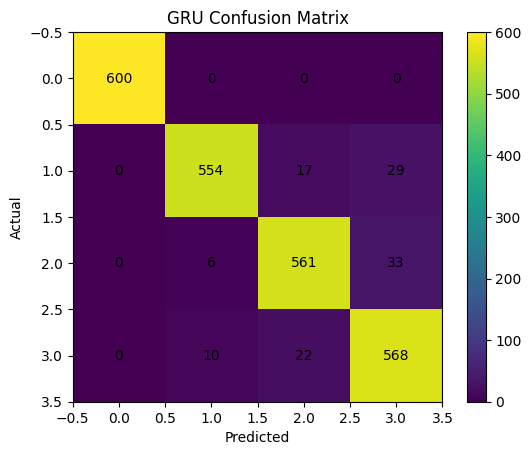

In [16]:
# Confusion Matrix
cm_gru = confusion_matrix(y_test, all_preds)
plt.figure()
plt.imshow(cm_gru)
plt.title("GRU Confusion Matrix")
plt.colorbar()
for i in range(cm_gru.shape[0]):
    for j in range(cm_gru.shape[1]):
        plt.text(j, i, cm_gru[i, j], ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# Part C: Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "GRU (PyTorch)"],
    "Accuracy": [accuracy_rf, accuracy_gru]
})

print("\nAccuracy Comparison Table:")
print(comparison_df)


Accuracy Comparison Table:
           Model  Accuracy
0  Random Forest   0.95625
1  GRU (PyTorch)   0.95125
